# Normalization assessment: Analysis of 10k windows at PASes

Rerun of 10k analysis of PASes. We previously showed the relationship between H3K56 acetylation and nucleosome stability for highly expressed genes. In the chromatin plots, however, there is a possible technical artifact in which the transition from G1 to S is not smooth (see note). This notebook aims to address, if we normalize the deconvolved f images, do we still retain the same acetylation result? Can we assess more time course specific dynamics once normalized?

Note: The source is not clear yet, but may become clear with some numerical analysis of the values within these occupancy histograms


---

It appears that normalization reduces the variation in the nucleosome occupancy. Thus decreasing the differential effect of seeing the gene body nucleosomes that are more variable in the highly transcribed genes.

Conclusion: Don't normalize the f images by total occupancy, because we lose some information. Rather, will need to understand better why the G1-S transition is so dramatic in overall occupancy change...


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolve_genome_g0066_10k_10x10_2024_09_20"
analysis = GenomeDeconvolutionAnalysis(outdir)


In [3]:
from src.geneset import get_deconvolved_geneset
genes = get_deconvolved_geneset()

In [4]:
from src.reference_data import load_h3k56ac_marks

nuc_h3k56ac_table = load_h3k56ac_marks()
genes_h3k56ac = nuc_h3k56ac_table.loc[~nuc_h3k56ac_table.acc.isna()]
genes_h3k56ac = genes_h3k56ac[['H3K56ac', 'acc']].groupby('acc').mean()
genes_h3k56ac = genes_h3k56ac.join(genes[['chr', 'strand', 'TSS', 'PAS']], how='inner')
genes_h3k56ac = genes_h3k56ac.rename(columns={'H3K56ac': 'mean_acetylation'})
genes_h3k56ac.head()

,mean_acetylation,chr,strand,TSS,PAS
YAL001C,-0.367917,1,-,151205,147540
YAL002W,-0.117391,1,+,143552,147566
YAL003W,0.106667,1,+,142154,143369
YAL005C,0.101429,1,-,141494,139358
YAL007C,0.150000,1,-,138421,137523


In [5]:
# Compute box plot information for the acetylation values for each 
# gene's nucleosome H3K56 acetylation.

h3k56_steady_state_acetylation = load_h3k56ac_marks(full=False)
h3k56ac_qs = h3k56_steady_state_acetylation[['H3K56ac', 'acc']].groupby('acc')\
    .quantile(q=[0.25, 0.5, 0.75]).unstack()
h3k56ac_qs.columns = h3k56ac_qs.columns.droplevel(0)
h3k56ac_qs = h3k56ac_qs.join(genes[['chr', 'strand', 'TSS', 'PAS']], how='inner')
h3k56ac_qs.head()

,0.25,0.5,0.75,chr,strand,TSS,PAS
YAL001C,-0.445,-0.310,-0.205,1,-,151205,147540
YAL002W,-0.415,-0.140,0.110,1,+,143552,147566
YAL003W,-0.190,-0.090,0.305,1,+,142154,143369
YAL005C,0.005,0.070,0.155,1,-,141494,139358
YAL007C,0.075,0.165,0.175,1,-,138421,137523


In [6]:
from src.gene_clustering import GeneClustering
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
gene_clustering = GeneClustering(outdir)


In [7]:
genes_replication = pd.read_csv('data/replication_timing/yl_2019/genes_replication_timing_shared.csv').set_index('orf_name')
genes_replication = genes_replication.sort_values('replication_time')

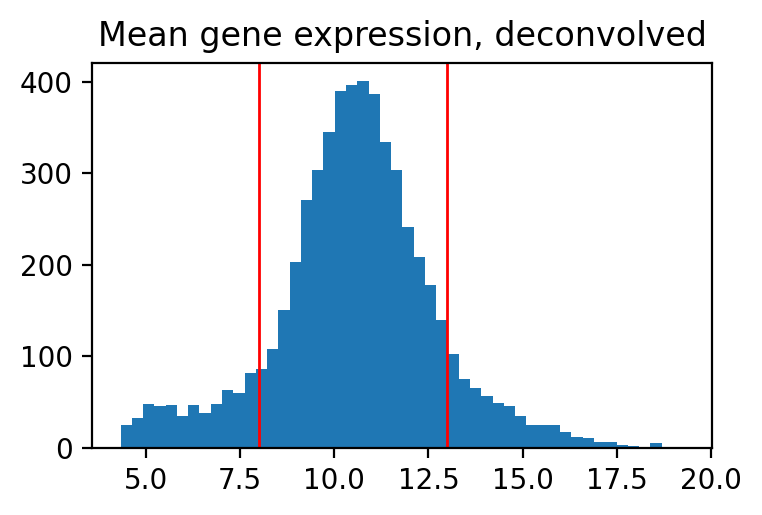

In [8]:
t_indices = gene_clustering.config.get_Hpositions_for_branch('t')
deconvolved_gene_expression_t = gene_clustering.gene_expression[t_indices]
plt.figure(figsize=(4, 2.5))
plt.hist(deconvolved_gene_expression_t.mean(axis=1), bins=50)
plt.title("Mean gene expression, deconvolved")
cutoffs = 8, 13
for cutoff in cutoffs:
    plt.axvline(cutoff, c='red', lw=1)

In [9]:
low_tx_genes = deconvolved_gene_expression_t[
    deconvolved_gene_expression_t.max(axis=1) < cutoffs[0]]
high_tx_genes = deconvolved_gene_expression_t[
    deconvolved_gene_expression_t.min(axis=1) > cutoffs[1]]
print(f"Low expressed genes: {len(low_tx_genes)}")
print(f"High expressed genes: {len(high_tx_genes)}")

Low expressed genes: 494
High expressed genes: 445


In [14]:
mean_low_tx_genes, low_tx_gb_nuc_occ = \
    analysis.load_stacked_mnase_data_for_genes(low_tx_genes, padding=1000,
                                              center_mode='PAS_nuc', normalize=True)

Failed to load 7 files


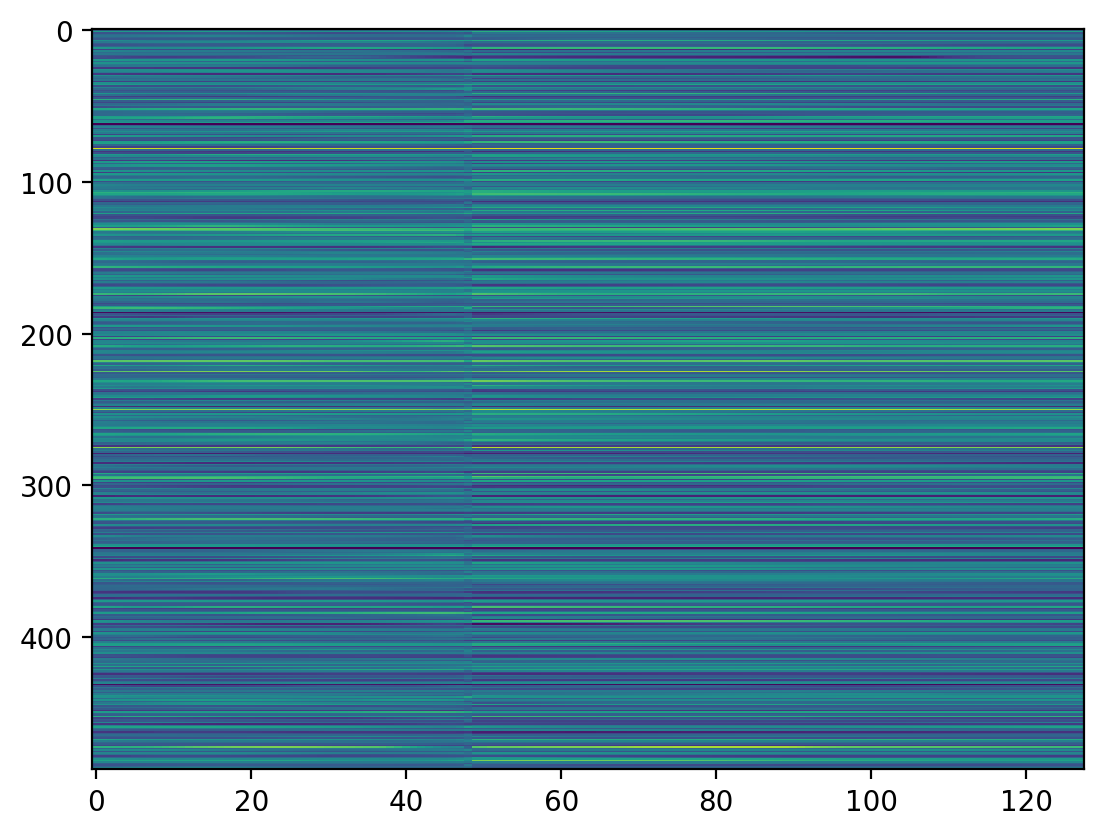

In [22]:
plt.imshow(low_tx_gb_nuc_occ.dropna().astype(float)[t_indices], aspect='auto', 
          interpolation='none', vmin=0, vmax=1000)

In [23]:
mean_high_tx_genes, high_tx_gb_nuc_occ = analysis.load_stacked_mnase_data_for_genes(
    high_tx_genes, padding=1000, center_mode='PAS_nuc', normalize=True)


In [24]:
normalized_low_tx_gb = (low_tx_gb_nuc_occ - \
    low_tx_gb_nuc_occ.mean(axis=1).values.reshape((-1,1)))/\
    low_tx_gb_nuc_occ.std(axis=1).values.reshape((-1,1))

normalized_high_tx_gb = (high_tx_gb_nuc_occ - \
    high_tx_gb_nuc_occ.mean(axis=1).values.reshape((-1,1)))/\
    high_tx_gb_nuc_occ.std(axis=1).values.reshape((-1,1))


Text(0.5, 0.98, 'Gene body nucleosome occupancy')

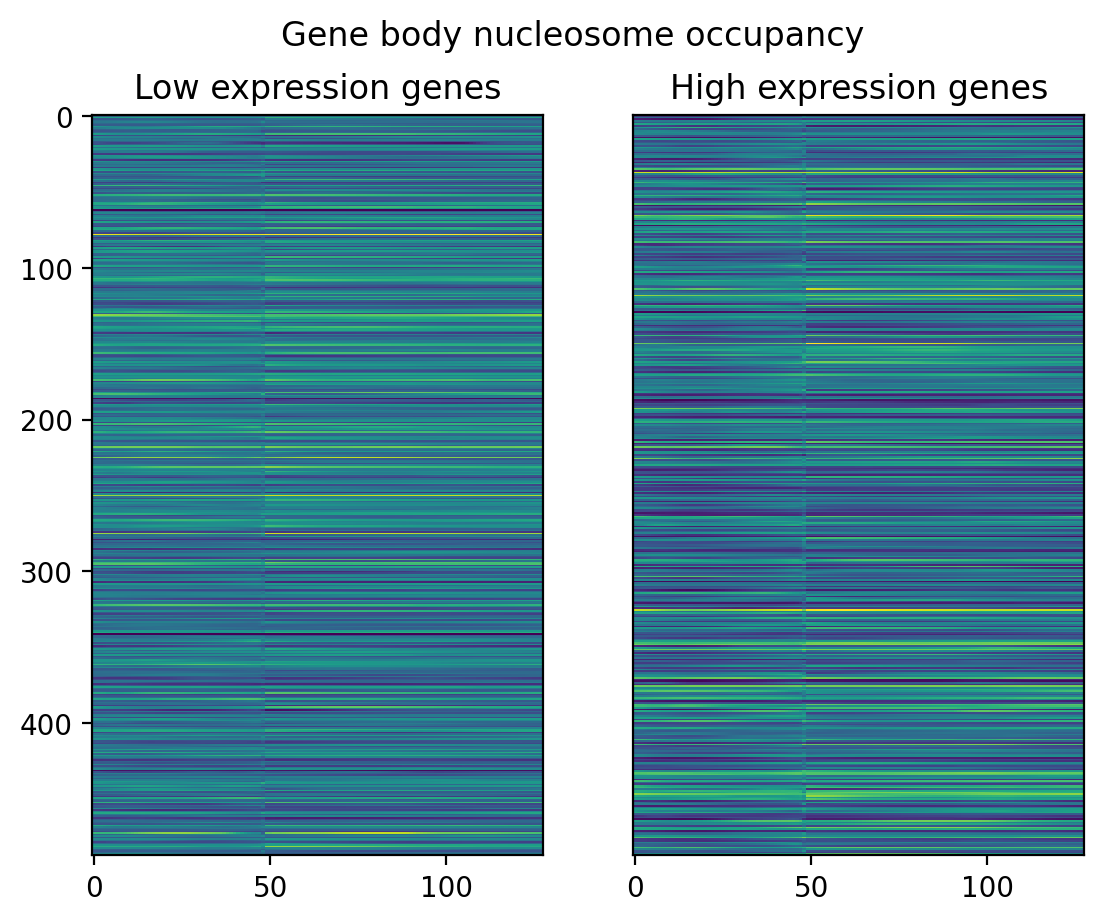

In [25]:
plt.subplot(1, 2, 1)
plt.imshow(low_tx_gb_nuc_occ.dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto')
plt.title("Low expression genes")

plt.subplot(1, 2, 2)
plt.imshow(high_tx_gb_nuc_occ.dropna().astype(float)[t_indices], aspect='auto', 
           interpolation='none')
plt.yticks([])
plt.title("High expression genes")

plt.suptitle("Gene body nucleosome occupancy")

In [26]:
sorted_low_tx_repl = genes_replication.loc[normalized_low_tx_gb.index]\
    .sort_values('replication_time').index
sorted_high_tx_repl = genes_replication.loc[normalized_high_tx_gb.index]\
    .sort_values('replication_time').index

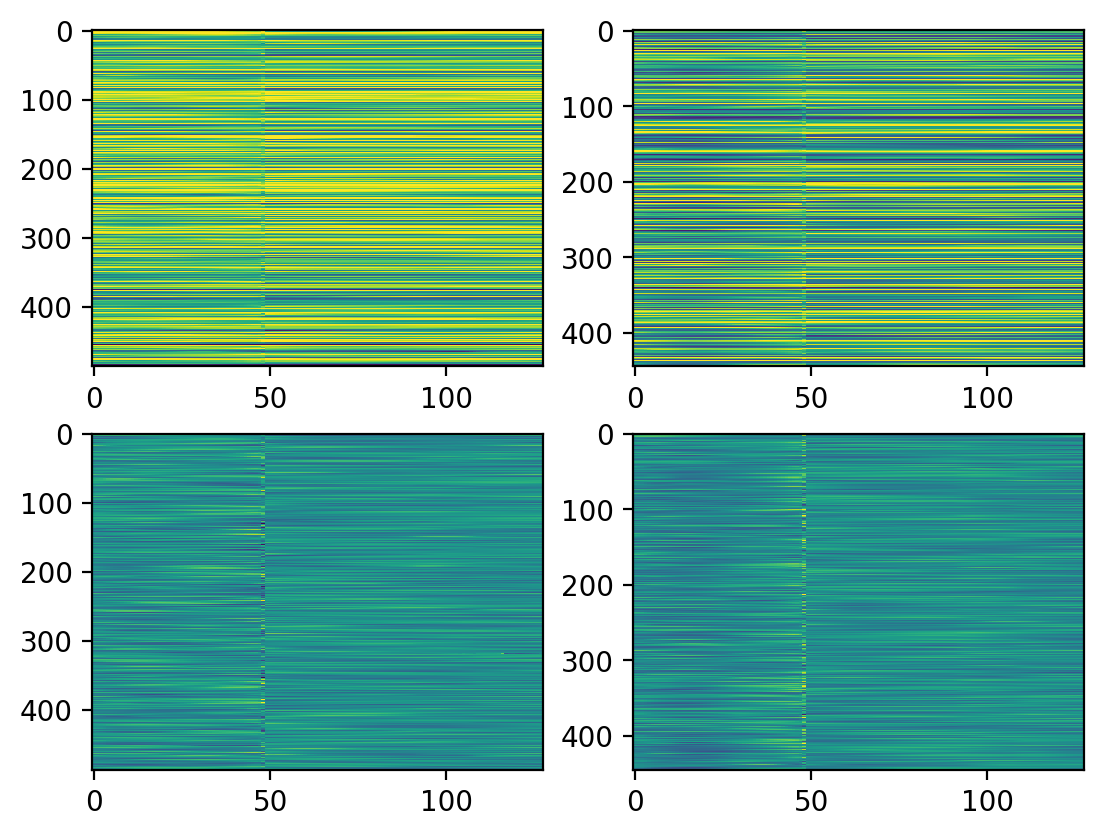

In [27]:
plt.subplot(2, 2, 1)
plt.imshow(low_tx_gb_nuc_occ.loc[sorted_low_tx_repl].dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto', vmin=0, vmax=500)
plt.subplot(2, 2, 2)
plt.imshow(high_tx_gb_nuc_occ.loc[sorted_high_tx_repl].dropna().astype(float)[t_indices], 
    aspect='auto', interpolation='none', vmin=0, vmax=500)

plt.subplot(2, 2, 3)
plt.imshow(normalized_low_tx_gb.loc[sorted_low_tx_repl].dropna().astype(float)[t_indices],
                     interpolation='none', aspect='auto', vmin=-5, vmax=5)
plt.subplot(2, 2, 4)
plt.imshow(normalized_high_tx_gb.loc[sorted_high_tx_repl].dropna().astype(float)[t_indices], 
    aspect='auto', interpolation='none', vmin=-5, vmax=5)


In [83]:
from sklearn.cluster import KMeans
n_clusters = 9
def cluster_gb_data(normalized_gb,_gb_nuc_occ):
    kmeans = KMeans(n_clusters=n_clusters, random_state=13, n_init="auto").fit(
       _gb_nuc_occ.dropna()[t_indices])

    clustered_gb =_gb_nuc_occ.dropna().copy()
    clustered_gb['cluster'] = kmeans.labels_+1
    clustered_gb = clustered_gb.reset_index().set_index(['cluster', 'orf_name'])
    clustered_gb = clustered_gb.sort_index()

    plt.subplot(1, 2, 1)
    plt.imshow(clustered_gb.astype(float)[t_indices],
                         interpolation='none', cmap="Spectral_r",
               aspect='auto', vmin=-2, vmax=2)
    plt.title("Raw")
    plt.subplot(1, 2, 2)
    plt.imshow(normalized_gb.loc[clustered_gb.reset_index().orf_name][t_indices]\
        .astype(float), aspect='auto', interpolation='none', vmin=0, vmax=800)
    plt.title("Normalized")
    
    return clustered_gb


Text(0.5, 0.98, 'Lowly expressed genes, n=494')

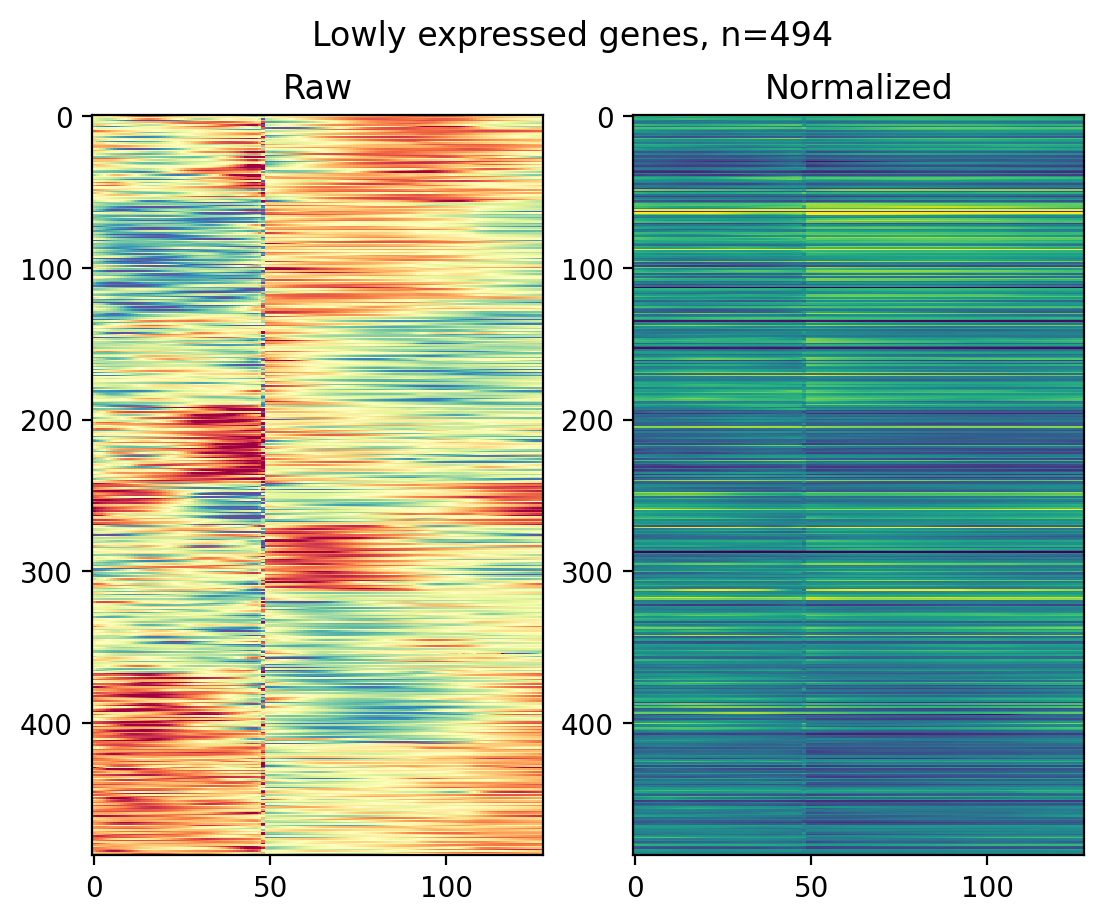

In [87]:
clustered_low_tx_gb = cluster_gb_data(low_tx_gb_nuc_occ, normalized_low_tx_gb)
plt.suptitle(f"Lowly expressed genes, n={len(low_tx_gb_nuc_occ)}")


Text(0.5, 0.98, 'Highly expressed genes, n=445')

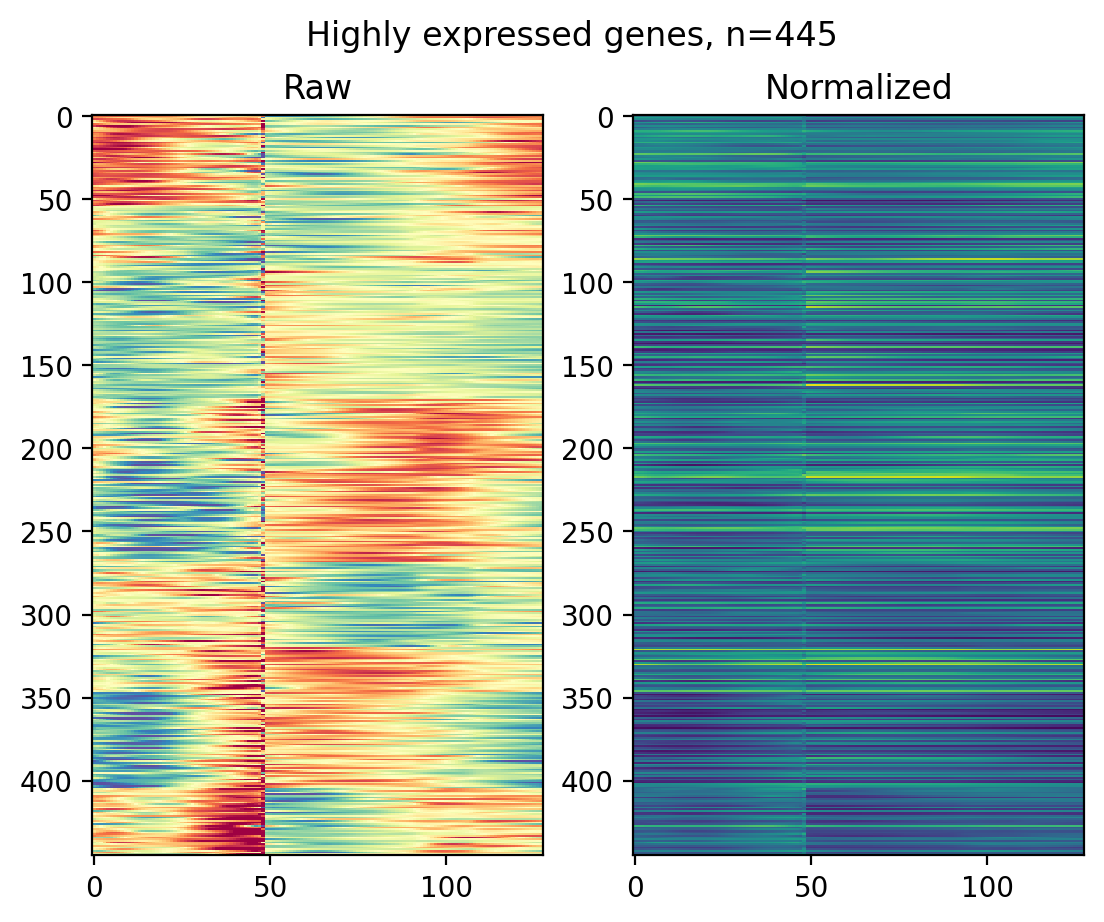

In [85]:
clustered_high_tx_gb = cluster_gb_data(high_tx_gb_nuc_occ, normalized_high_tx_gb)
plt.suptitle(f"Highly expressed genes, n={len(high_tx_gb_nuc_occ)}")

In [86]:
s_g2m_indices = gene_clustering.config.get_Hpositions_for_phase('postG1')

high_std = high_tx_gb_nuc_occ[s_g2m_indices].std(axis=1).mean()
low_std = low_tx_gb_nuc_occ[s_g2m_indices].std(axis=1).mean()

print(f"Genes with a low baseline expression, "
      f"exhibit a higher variation in nucleosome occupancy of {low_std:.2f}")
print(f"Compared to genes with high expression,"
      f"a standard deviation of {high_std:.2f}")
print(f"This appears to show that replication effects on the chromatin are clearest"
      f"with lowly expressed genes.")


Genes with a low baseline expression, exhibit a higher variation in nucleosome occupancy of 23.89
Compared to genes with high expression,a standard deviation of 25.50
This appears to show that replication effects on the chromatin are clearestwith lowly expressed genes.


In [68]:
def compute_box_cluster_vals(clustered_tx_gb):
    from scipy.stats import pearsonr
    clusters = clustered_tx_gb.index.get_level_values(0).unique()
    box_cluster_vals = pd.DataFrame(columns=['n', 'n_acetylation', 
                                             'pearsonr', 'pearsonr_pval',
                                             'sg2m_variation', 
                                             'lower', 'median', 'upper'],
                                    index=clusters)

    for cluster in clusters:
        cluster_orfs = clustered_tx_gb.loc[cluster].index
        
        # The nucleosome variation during S-phase and G2/M
        cluster_gb_std = clustered_tx_gb.loc[cluster][s_g2m_indices].std(axis=1)
        box_cluster_vals.loc[cluster, 'sg2m_variation'] = cluster_gb_std.std()
        
        acetylation_values = genes_h3k56ac.join(pd.DataFrame(index=cluster_orfs), 
            how='inner').mean_acetylation
        
        box_vals = np.quantile(acetylation_values, q=[0.25, 0.5, 0.75])
        box_cluster_vals.loc[cluster, ['lower', 'median', 'upper']] = box_vals

        current_gb_std = clustered_tx_gb.loc[cluster][s_g2m_indices].std(axis=1)\
            .loc[acetylation_values.index]

        if len(acetylation_values) > 1:
            pearsonr_val, pval = pearsonr(acetylation_values, current_gb_std)
        else:
            pearsonr_val = np.nan
            pval = np.nan
                                       
        box_cluster_vals.loc[cluster, 'pearsonr'] = pearsonr_val
        box_cluster_vals.loc[cluster, 'pearsonr_pval'] = pval
        box_cluster_vals.loc[cluster, 'n'] = len(cluster_orfs)
        box_cluster_vals.loc[cluster, 'n_acetylation'] = len(acetylation_values)
        
    return box_cluster_vals


In [69]:
hi_box_cluster_vals = compute_box_cluster_vals(clustered_high_tx_gb)
low_box_cluster_vals = compute_box_cluster_vals(clustered_low_tx_gb)

In [70]:
hi_box_cluster_vals.sort_values('pearsonr')

,n,n_acetylation,pearsonr,pearsonr_pval,sg2m_variation,lower,median,upper
cluster,,,,,,,,
6,51,51,-0.296566,0.034584,0.190209,-0.093676,0.304286,0.662619
9,40,40,-0.193487,0.231596,0.24866,-0.125357,-0.010075,0.274896
4,42,42,-0.167842,0.288022,0.213449,-0.165363,0.075541,0.365673
1,55,55,-0.065784,0.633234,0.22401,-0.155893,0.127778,0.5675
3,79,77,0.016043,0.889858,0.201501,0.021429,0.278,0.566667
7,27,27,0.018132,0.928475,0.226389,-0.136905,0.083333,0.3385
8,58,57,0.05498,0.684593,0.201331,0.222308,0.44,0.7025
2,37,36,0.092435,0.591828,0.245379,-0.075507,0.291032,0.5025
5,56,56,0.230788,0.087027,0.176819,-0.004063,0.205,0.472857


In [88]:
low_box_cluster_vals.sort_values('pearsonr')

,n,n_acetylation,pearsonr,pearsonr_pval,sg2m_variation,lower,median,upper
cluster,,,,,,,,
20,2,2,-1.0,1.0,9.526327,-0.3365,-0.313,-0.2895
21,5,5,-0.843822,0.07233,9.14305,-0.233333,-0.128235,-0.055
8,3,3,-0.619644,0.574554,10.67819,-0.0575,0.0475,0.14375
23,18,18,-0.395752,0.10402,15.141874,-0.2955,-0.0275,0.106667
5,9,8,-0.344809,0.4029,13.551955,-0.0025,0.118429,0.298333
3,29,28,-0.288105,0.137085,10.992291,-0.110651,0.010417,0.163125
6,14,14,-0.226923,0.435292,17.961169,-0.03375,0.22,0.5055
10,4,4,-0.168747,0.831253,5.060973,-0.135952,0.050779,0.288864
9,31,30,-0.133106,0.483176,10.955197,-0.48,-0.207333,0.371786


In [72]:
def compute_compare_gb_h3k56ac(high_tx_gb_nuc_occ):
    gb_std = high_tx_gb_nuc_occ[s_g2m_indices].std(axis=1)
    cur_gene_acetylation = high_tx_gb_nuc_occ[[]].join(genes_h3k56ac, 
        how='left').mean_acetylation
    compare_gb_nuc_df = pd.DataFrame({'gene_body_std': gb_std, 
        'h3k56acetylation': cur_gene_acetylation})
    return compare_gb_nuc_df


In [73]:
high_gb_nuc_df = compute_compare_gb_h3k56ac(high_tx_gb_nuc_occ)
low_gb_nuc_df = compute_compare_gb_h3k56ac(low_tx_gb_nuc_occ)


In [81]:
# selected_cluster = 9
# selected_orfs = clustered_low_tx_gb.loc[selected_cluster].index
# selected_data = low_gb_nuc_df.loc[selected_orfs]

selected_cluster = 6
selected_orfs = clustered_high_tx_gb.loc[selected_cluster].index
selected_data = high_gb_nuc_df.loc[selected_orfs]

Text(0.5, 1.0, 'PAS - Variation in nucleosome occupancy\nvs H3K56 acetylation')

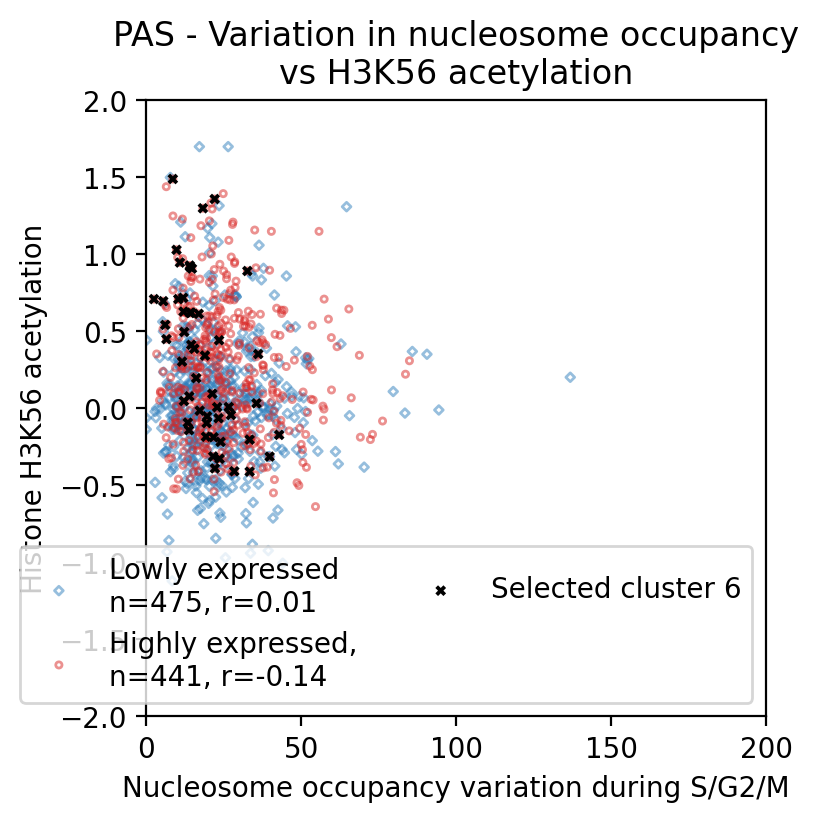

In [82]:
from scipy.stats import pearsonr

plt.figure(figsize=(4, 4))
x, y = low_gb_nuc_df.dropna().gene_body_std, \
    low_gb_nuc_df.dropna()['h3k56acetylation']
pearsonr_res, _ = pearsonr(x, y)
plt.scatter(x, y,
           label=f"Lowly expressed\nn={len(x)}, r={pearsonr_res:.2f}", 
            marker='D', facecolor='none',
           edgecolor=plt.get_cmap("Blues")(0.7), alpha=0.5, s=5)

x, y = high_gb_nuc_df.dropna().gene_body_std, \
    high_gb_nuc_df.dropna()['h3k56acetylation']
pearsonr_res, _ = pearsonr(x, y)
plt.scatter(x, y, 
            label=f"Highly expressed,\nn={len(x)}, "
                  f"r={pearsonr_res:.2f}", 
            edgecolor=plt.get_cmap('Reds')(0.7),
            facecolor='none', marker='o', alpha=0.5, s=5)

plt.scatter(selected_data.gene_body_std, selected_data['h3k56acetylation'],
          label=f"Selected cluster {selected_cluster}", marker='X', 
           color='black', edgecolor='none', lw=1, alpha=1, s=15)

plt.xlabel("Nucleosome occupancy variation during S/G2/M")
plt.ylabel("Histone H3K56 acetylation")
plt.legend(loc='lower right', ncol=2)

plt.xlim(0, 200)
plt.ylim(-2, 2)
plt.title("PAS - Variation in nucleosome occupancy\nvs H3K56 acetylation")

In [76]:
def plot_box_plot_acetylation_nuc_var(high_gb_nuc_df, c, title):
    
    x, y = high_gb_nuc_df.dropna().gene_body_std, high_gb_nuc_df.dropna()['h3k56acetylation']
    pearsonr_res, _ = pearsonr(x, y)
    current_box_values = h3k56ac_qs.loc[x.index]
    for orf_name, row in current_box_values.iterrows():
        x_val = x.loc[orf_name]
        plt.plot([x_val, x_val], [row[0.25], row[0.75]], c=c, lw=0.25, alpha=0.5)
        plt.scatter([x_val], [row[0.5]], color=c, s=1, alpha=0.5)
    plt.ylim(-2, 2)
    plt.xlim(0, 150)
    plt.title(f"{title}, n={len(x)}, r={pearsonr_res:.2f}")

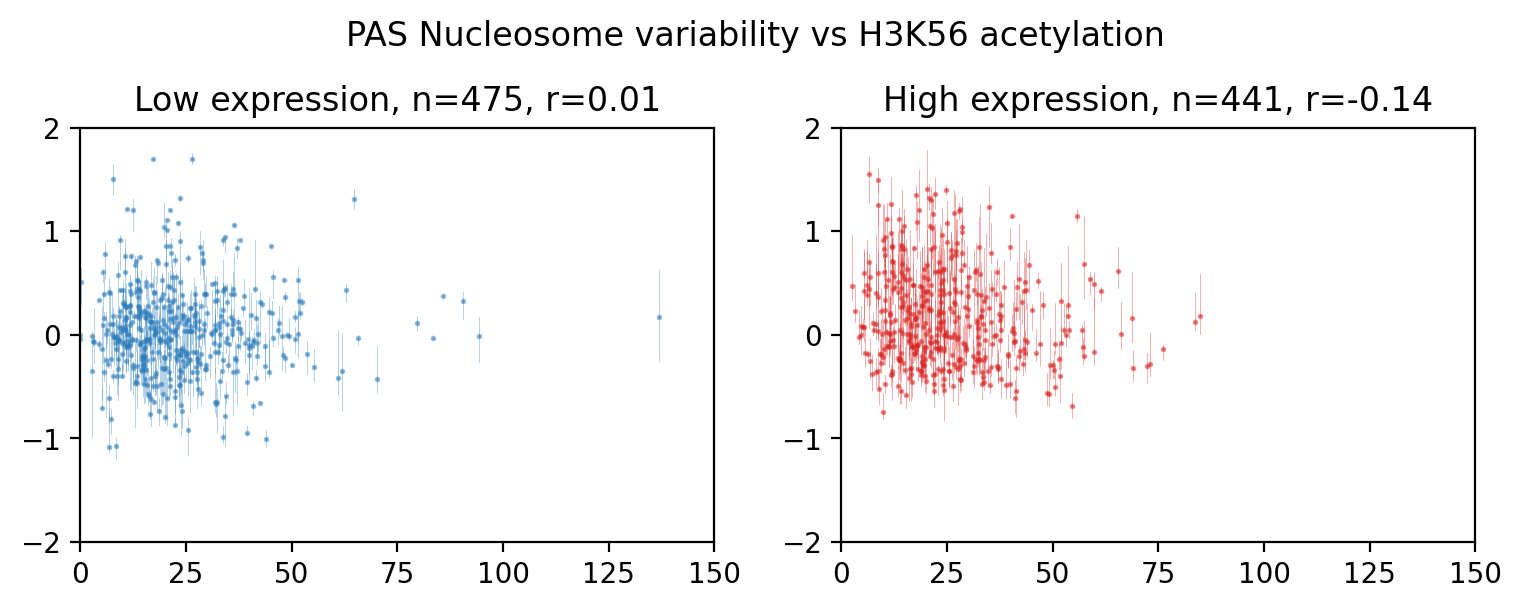

In [77]:
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plot_box_plot_acetylation_nuc_var(low_gb_nuc_df, c=plt.get_cmap('Blues')(0.7),
                                 title="Low expression")
plt.subplot(1, 2, 2)
plot_box_plot_acetylation_nuc_var(high_gb_nuc_df, c=plt.get_cmap('Reds')(0.7), 
                                 title="High expression")

plt.suptitle("PAS Nucleosome variability vs H3K56 acetylation")
plt.subplots_adjust(top=0.8)

In [42]:
# High acetylation, high expression -> low nucleosome variability
# 0 acetylation, high expression -> high nucleosome variability
sorted_high_tx_genes = high_gb_nuc_df.sort_values('h3k56acetylation').dropna()
high_acetyl_high_tx_genes = sorted_high_tx_genes.head(100)
low_acetyl_high_tx_genes = sorted_high_tx_genes.tail(100)


In [53]:
high_acetyl_high_f_imgs, _ = \
    analysis.load_stacked_mnase_data_for_genes(high_acetyl_high_tx_genes, padding=1000,
                                              center_mode='PAS_nuc', normalize=True)

low_acetyl_high_f_imgs, _ = \
    analysis.load_stacked_mnase_data_for_genes(low_acetyl_high_tx_genes, padding=1000,
                                              center_mode='PAS_nuc', normalize=True)



Text(0.5, 0.98, 'Highly expressed, high acetylation genes, n=100')

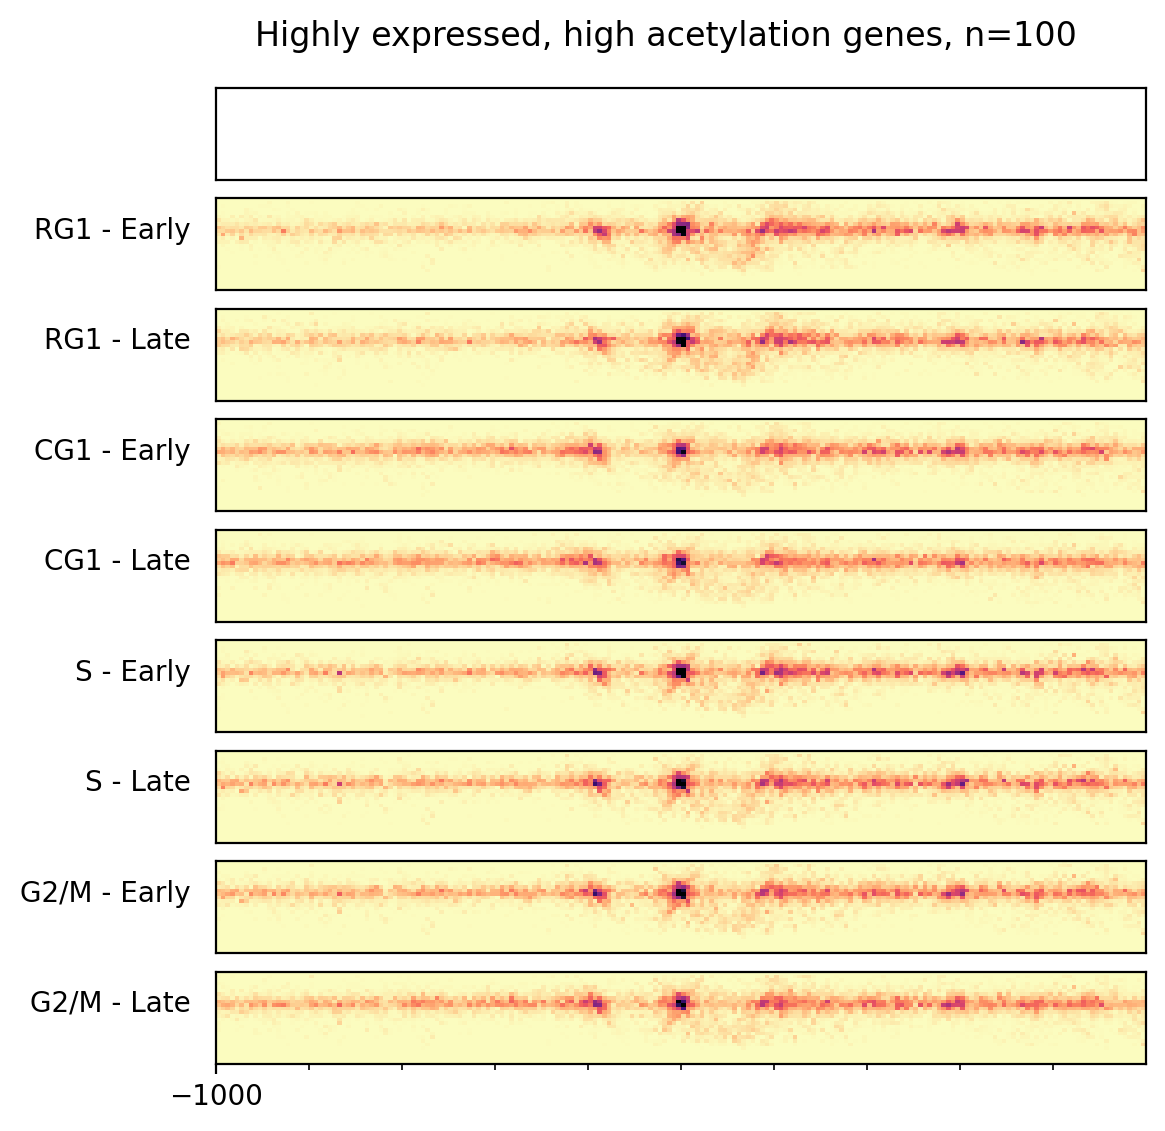

In [54]:
fig = analysis.plot_deconvolved_result(high_acetyl_high_f_imgs, (-1000, 1000), 
                                       figsize=(6, 6),
                                      vmax=5)
plt.suptitle(f"Highly expressed, high acetylation genes, n={len(high_acetyl_high_tx_genes)}")

Text(0.5, 0.98, 'Highly expressed, low acetylation genes, n=100')

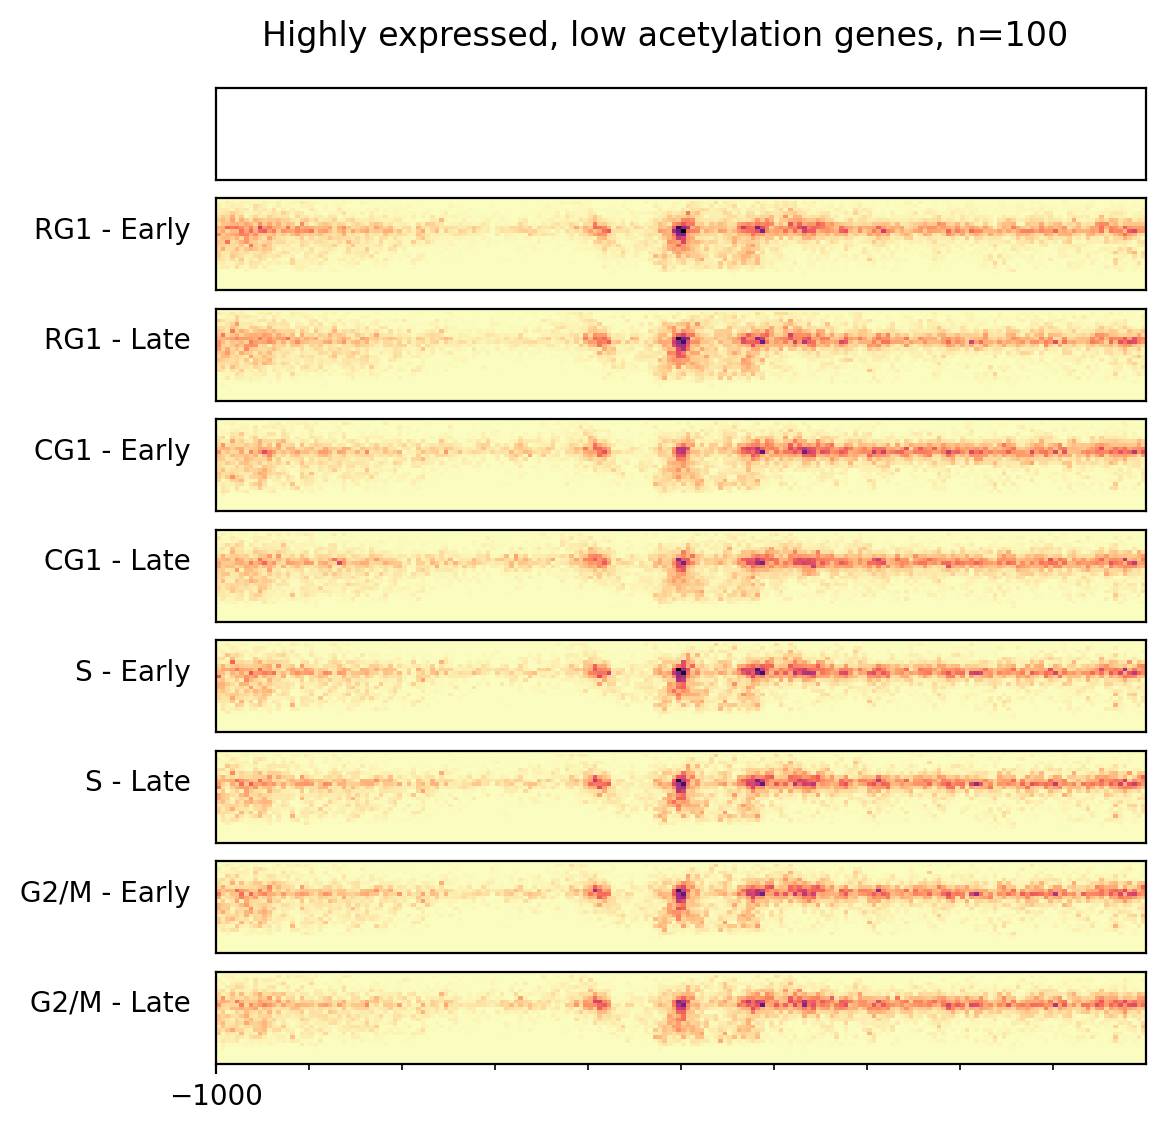

In [55]:
fig = analysis.plot_deconvolved_result(low_acetyl_high_f_imgs, (-1000, 1000), 
                                       figsize=(6, 6),
                                      vmax=5)
plt.suptitle(f"Highly expressed, low acetylation genes, n={len(low_acetyl_high_tx_genes)}")

In [46]:
from src.panther_go import PantherDBGO

panthergo = PantherDBGO()

cluster_go_df = pd.DataFrame()
for selected_cluster in np.arange(n_clusters)+1:

    selected_orfs = clustered_high_tx_gb.loc[selected_cluster].index
    selected_gene_names = genes.loc[selected_orfs]['gene']

    panthergo.run_go(selected_gene_names)
    panthergo.parse_response()
    go_results = panthergo.results_df.sort_values('fdr')

    go_results['cluster'] = selected_cluster
        
    cluster_go_df = pd.concat([cluster_go_df, go_results])


In [47]:
cluster_go_df[(cluster_go_df.cluster == 6) & 
              (cluster_go_df.number_in_reference < 100) &
              (cluster_go_df.fdr < 0.01)][['label', 'fdr']]


,label,fdr
1,lysine metabolic process,0.001977
0,lysine biosynthetic process,0.002911


In [343]:
# Next question, if we were to normalize the gene windows prior to computing the gene body nucleosome
# occupancy, would we still get the same result?
